In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy.stats as stats

from wordcloud import WordCloud
import plotly.graph_objects as go

# plt.rcParams['font.family'] = 'Arial'

# 乘客特征分析可视化

## 不同类型乘客的占比可视化

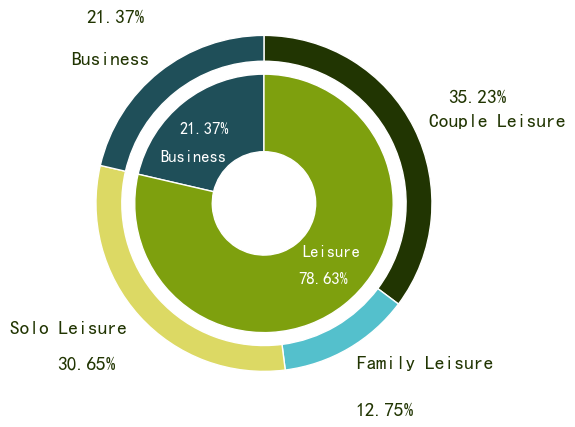

In [2]:
# 定义数据
data = pd.read_csv('./data/traveller_type_analysis.csv')

TravelType = data.iloc[:, 0]
Ratio = data.iloc[:, 2]/100


# 内圈数据
inner_labels = ['Business', 'Leisure']
inner_sizes = [Ratio[3], 1-Ratio[3]]
inner_colors = ['#1F4F59', '#7EA00E']

# 外圈数据
outer_labels = TravelType
outer_sizes = Ratio
outer_colors = ['#213502', '#54C0CC', '#DCD964', '#1F4F59']

# 创建饼图
fig, ax = plt.subplots()

# 内圈
ax.pie(inner_sizes, labels=inner_labels, labeldistance=0.47, colors=inner_colors, radius=1, autopct='%1.2f%%',
       pctdistance=0.74, wedgeprops=dict(width=0.6, edgecolor='w'), startangle=90, textprops={'color': 'white', 'fontsize': 12})

# 外圈
ax.pie(outer_sizes, labels=outer_labels, colors=outer_colors, radius=1.3, autopct='%1.2f%%', pctdistance=1.42, wedgeprops=dict(
    width=0.2, edgecolor='w'), startangle=90, counterclock=False, textprops={'color': '#213502', 'fontsize': 14})


# 确保饼图是圆的
ax.axis('equal')

# 显示图形
plt.show()

## 商务和休闲乘客数随时间的变化趋势可视化

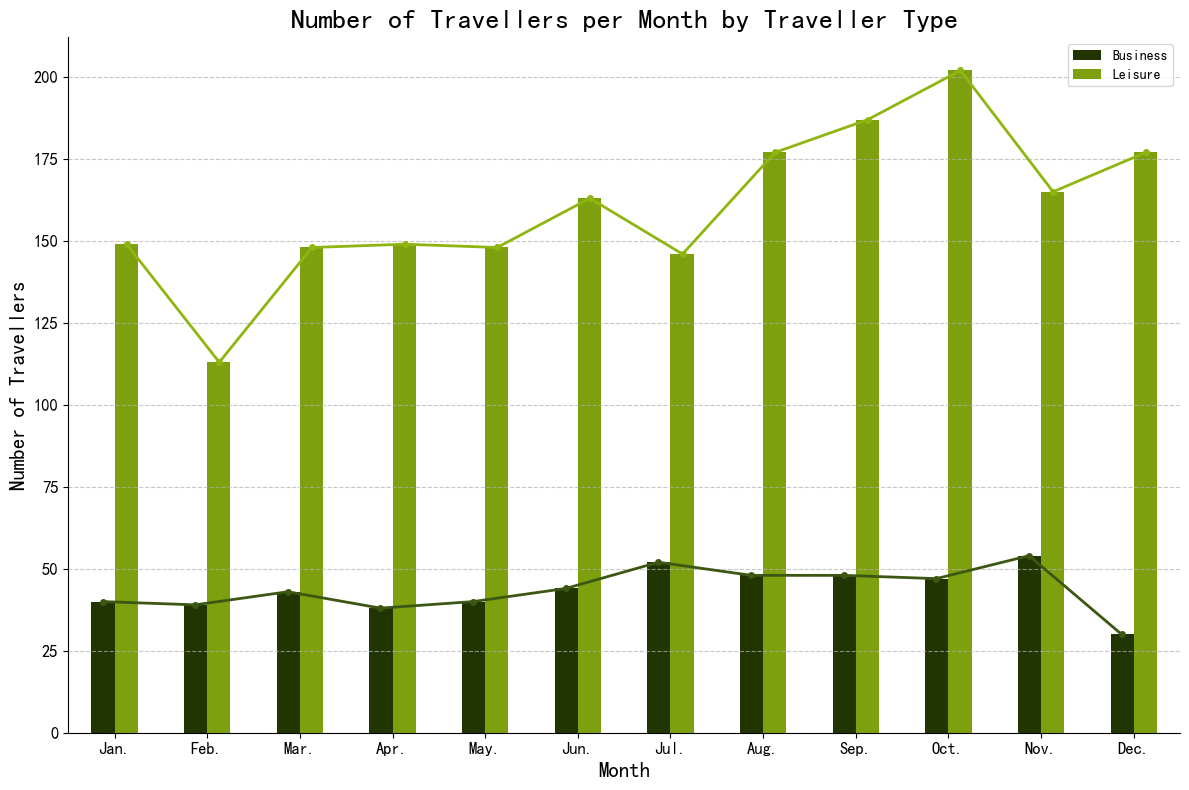

In [3]:
# 读取数据
data = pd.read_csv('./data/traveller_analysis.csv')
# 自定义月份顺序
custom_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May',
                'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# 将月份列转换为Categorical类型，并按照指定顺序排序
data['DateFlown'] = pd.Categorical(
    data['DateFlown'], categories=custom_order, ordered=True)
# 按不同旅行目的分别统计不同月份对应的数量
monthly_data = data.groupby([data.columns[1], data.columns[0]])[
    data.columns[2]].sum().unstack()

bar_colors = ['#213502', '#7EA00E']
labels = ['Jan.', 'Feb.', 'Mar.', 'Apr.', 'May.', 'Jun.',
          'Jul.', 'Aug.', 'Sep.', 'Oct.', 'Nov.', 'Dec.']
# 绘制条形图
monthly_data.plot(kind='bar', figsize=(12, 8), color=bar_colors)

index = [-1, 1]
line_colors = ['#3c5713', '#8fb610']
# 绘制折线图
for i, col in enumerate(monthly_data.columns):
    plt.plot([x + 0.13*index[i] for x in range(len(labels))], monthly_data[col],
             marker='o', linestyle='-', linewidth=2, markersize=4, color=line_colors[i])

# 设置标题
plt.title('Number of Travellers per Month by Traveller Type', fontsize=20)
# 设置x轴标签
plt.xlabel('Month', fontsize=15)
# 设置y轴标签
plt.ylabel('Number of Travellers', fontsize=15)
# 设置x轴刻度
plt.xticks(rotation=0, ticks=range(len(labels)), labels=labels, fontsize=12)
# 设置y轴刻度
plt.yticks(fontsize=12)
# 设置图例
plt.legend()
# 隐藏顶部及右侧边框
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)
# 调整布局
plt.tight_layout()
# 保存图形
# plt.savefig('saved_plot.png', dpi=600)
# 显示图形
plt.show()

## 不同舱位乘客的评分分布可视化

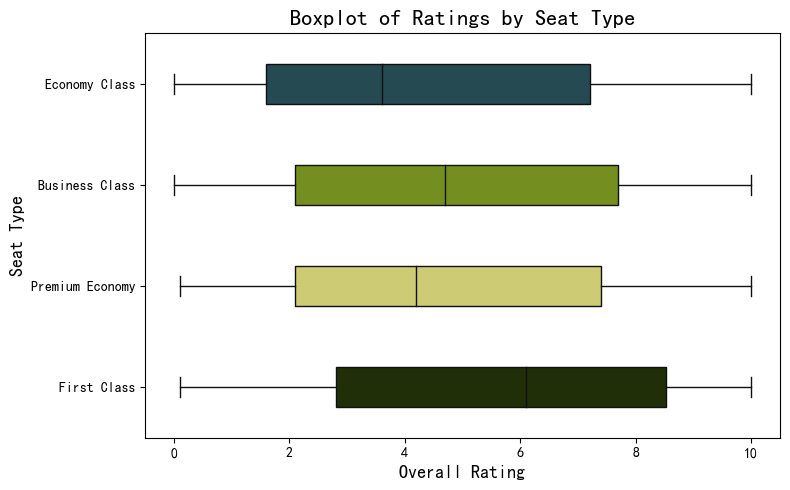

In [4]:
data = pd.read_csv('./data/seat_type_analysis.csv')

colors = ['#1F4F59', '#7EA00E', '#DCD964', '#213502']

# 绘制箱线图
plt.figure(figsize=(8, 5))
sns.boxplot(x=data.iloc[:, 1], y=data.iloc[:, 0], palette=colors, width=0.4, linewidth=1)
plt.title('Boxplot of Ratings by Seat Type', fontsize=16)
plt.xlabel('Overall Rating', fontsize=13)
plt.ylabel('Seat Type', fontsize=13)
plt.grid(False)
plt.tight_layout()
plt.show()


# 航线分析

## 统计Top10热门出发地&目的地的航线可视化

In [6]:
data = pd.read_csv('./data/hot_city_analysis.csv')

# 将 'Departure' 字段的所有值后面都补1
data['Departure'] = data['Departure'].astype(str) + '1'

# 将 'Destination' 字段的所有值后面都补0
data['Destination'] = data['Destination'].astype(str) + '0'

# 获取唯一标签并创建索引映射
all_labels = list(set(data['Departure']).union(set(data['Destination'])))
label_indices = {label: i for i, label in enumerate(all_labels)}

# 创建sources, targets, values列表
sources = [label_indices[dep] for dep in data['Departure']]
targets = [label_indices[des] for des in data['Destination']]
values = data['count'].tolist()

labels = list(label_indices.keys())
labels = [label[:-1] for label in all_labels]

# 创建桑基图
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.01),
        label=labels,
        color="#213502",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color="rgba(0, 0, 0, 0.5)"  # 设置链接颜色为半透明黑色
    )
)])

fig.update_layout(title_text="统计Top10热门出发地&目的地的航线可视化", font_size=20)
fig.show()

# 乘客情感分析可视化

## 常见表扬词和常见批评词可视化

In [13]:
def read_csv(file_path):
    data = pd.read_csv(file_path, usecols=[0, 1], nrows=20)
    data.columns = ['word', 'frequency']
    return data

def generate_wordcloud(words_freq, ax, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(words_freq)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontdict={'fontsize': 25})

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

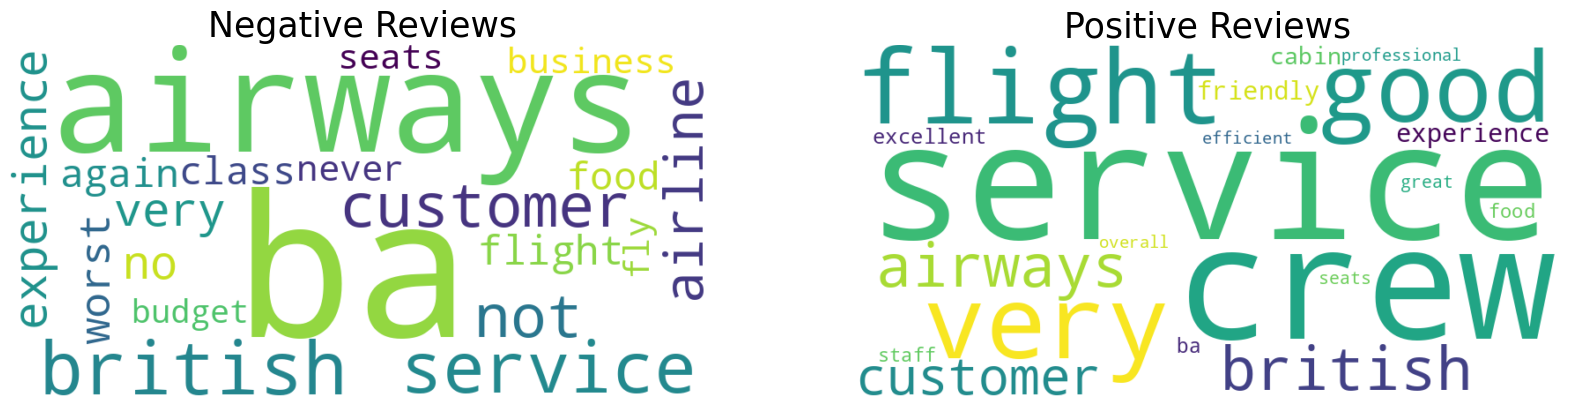

In [14]:
# 读取负面评论CSV文件并生成词云数据
file_path_neg = './data/negative_reviews.csv' 
data_negative = read_csv(file_path_neg)
words_freq_negative = dict(zip(data_negative['word'], data_negative['frequency']))

# 读取正面评论CSV文件并生成词云数据
file_path_pos = './data/positive_reviews.csv'
data_positive = read_csv(file_path_pos)
words_freq_positive = dict(zip(data_positive['word'], data_positive['frequency']))

# 创建一个包含两个子图的图形
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# 生成并显示负面评论词云
generate_wordcloud(words_freq_negative, axs[0], 'Negative Reviews')

# 生成并显示正面评论词云
generate_wordcloud(words_freq_positive, axs[1], 'Positive Reviews')

# 展示图形
plt.show()

## 情感分析与总体评分的相关性可视化

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

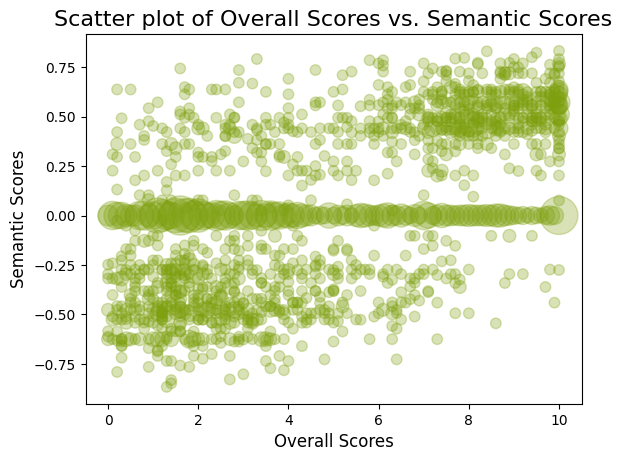

In [15]:
data = pd.read_csv('./data/sentiment_analysis.csv')

# 获取总体评分和语义评分
overall_scores = data.iloc[:, 0]
semantic_scores = data.iloc[:, 1]

counts = data.iloc[:, 2]
normalized_counts = np.array(counts) / max(counts)
mapped_counts = normalized_counts * (800 - 30) + 30

# 绘制散点图
plt.scatter(overall_scores, semantic_scores, color='#7EA00E', alpha=0.3, s=mapped_counts)
plt.title('Scatter plot of Overall Scores vs. Semantic Scores', fontsize=16)
plt.xlabel('Overall Scores', fontsize=12)
plt.ylabel('Semantic Scores', fontsize=12)
plt.grid(False)
plt.show()

# 飞机体验分析可视化

## 全部乘客的总体评分分布可视化

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

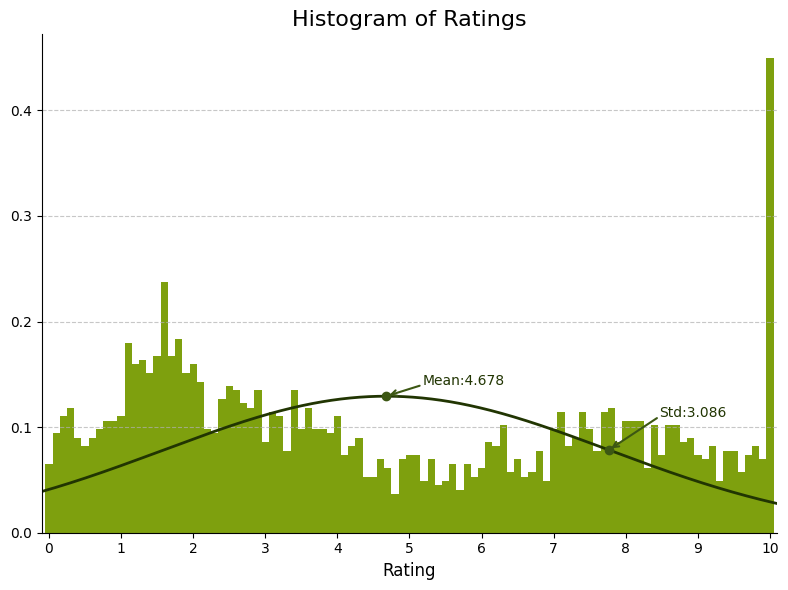

In [16]:
data = pd.read_csv('./data/rating_analysis.csv')

ratings = data.iloc[:, 0]
counts = data.iloc[:, 1]
counts_freq = counts/np.sum(counts)*10

# 绘制直方图
plt.figure(figsize=(8, 6))
plt.bar(ratings, counts_freq, color='#7EA00E', width=0.1)

mu = np.sum(ratings * counts) / np.sum(counts)
sigma = np.sqrt(np.sum(counts * (ratings - mu)**2) / np.sum(counts))

x = np.linspace(-1, 12, 1500)
y = 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-(x - mu)**2 / (2 * sigma**2))
plt.plot(x, y, color='#213502', linestyle='-', linewidth=2)

plt.scatter(mu, 1/(sigma * np.sqrt(2 * np.pi)), color='#3c5713', zorder=4)
plt.text(mu+0.5, 0.14, f'Mean:{mu:.3f}', color='#213502', ha='left')
plt.annotate('', xy=(mu, 1/(sigma * np.sqrt(2 * np.pi))), xytext=(mu+0.5, 0.14),
             arrowprops=dict(color='#3c5713', linewidth=1.5, arrowstyle='->'))

plt.scatter(mu+sigma, 1/(sigma * np.sqrt(2 * np.pi))
            * np.exp(-1/2), color='#3c5713', zorder=4)
plt.text(mu+sigma+0.7, 0.11, f'Std:{sigma:.3f}', color='#213502', ha='left')
plt.annotate('', xy=(mu+sigma, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-1/2)), xytext=(mu +
             sigma+0.7, 0.11), arrowprops=dict(color='#3c5713', linewidth=1.5, arrowstyle='->'))

# 设置标题
plt.title('Histogram of Ratings', fontsize=16)
plt.xlim(-0.1, 10.1)
# 设置x轴标签
plt.xlabel('Rating', fontsize=12)
# 设置x轴刻度
plt.xticks(ticks=range(11), fontsize=10)
# 设置y轴刻度
plt.yticks(fontsize=10)
# 隐藏顶部及右侧边框
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 添加网格线
plt.grid(False)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# 调整布局
plt.tight_layout()
# 保存图形
# plt.savefig('saved_plot.png', dpi=600)
# 显示图形
plt.show()

## 各项评分指标中排名最高的10款机型可视化

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

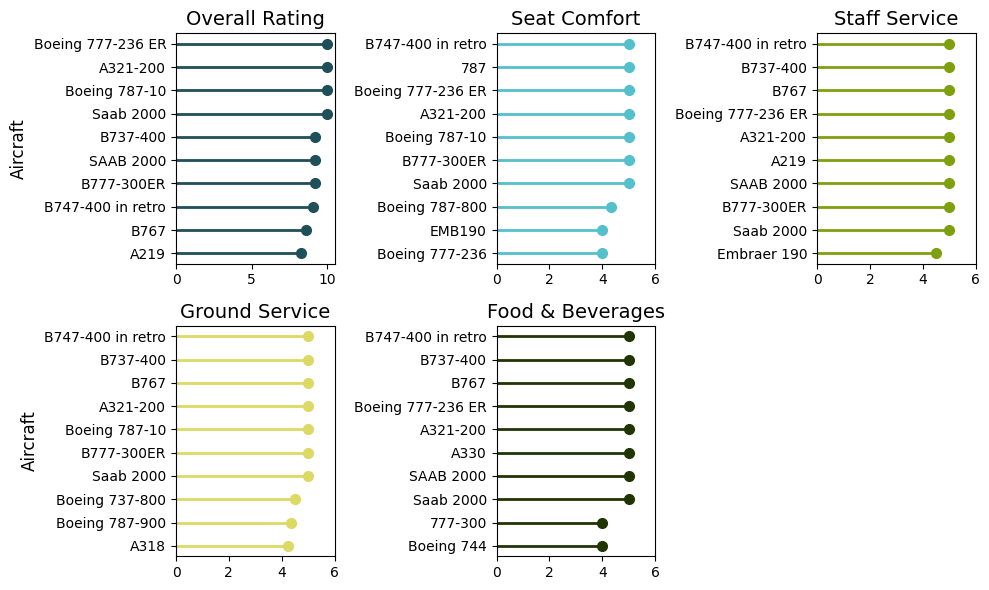

In [17]:
files = [
    './data/overall_rating_analysis.csv',
    './data/seat_comfort_analysis.csv',
    './data/staff_service_analysis.csv',
    './data/ground_service_analysis.csv',
    './data/food_beverages_analysis.csv'
]

num_files = len(files)
num_cols = 3
num_rows = (num_files + num_cols - 1) // num_cols

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 6))
xlim = [10.5, 6, 6, 6, 6]
colors = ['#1F4F59', '#54C0CC', '#7EA00E', '#DCD964', '#213502']
labels = ['Overall Rating', 'Seat Comfort', 'Staff Service', 'Ground Service', 'Food & Beverages']

for i, file in enumerate(files):
    data = pd.read_csv(file)
    
    categories = data.iloc[:10, 0]
    categories = categories[::-1]
    ratings = data.iloc[:10, 1]
    ratings = ratings[::-1]
    
    ax = axes[i // num_cols, i % num_cols]
    
    ax.hlines(y=categories, xmin=0, xmax=ratings, linewidth=2, color=colors[i])
    ax.plot(ratings, categories, "o", markersize=7, color=colors[i])
    ax.set_xlim(0, xlim[i])
    ax.set_title(labels[i], fontsize=14)
    if i == 0 or i == 3:
        ax.set_ylabel(data.columns[0], fontsize=12)
    ax.grid(False)
    
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])
    
plt.tight_layout()
plt.show()

### 热门机型中各项评分指标的分布可视化

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

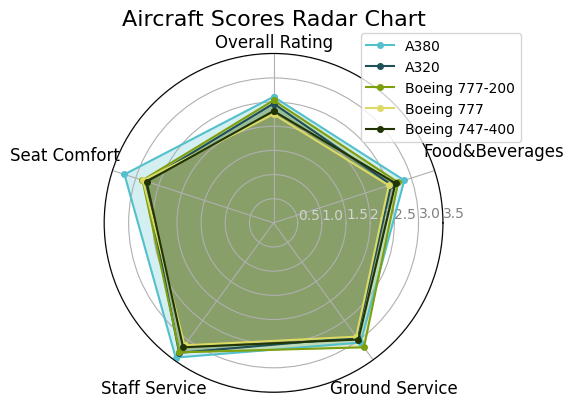

In [18]:
data = pd.read_csv('./data/aircrafts_scores_analysis.csv')

# 获取Aircraft和评分列名
aircrafts = data.iloc[:, 0]
score_columns = data.columns[1:]

num_vars = len(score_columns)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
for index, angle in enumerate(angles):
    angle += 0.5 * np.pi
    if angle >= 2 * np.pi:
        angle -= 2 * np.pi
    angles[index] = angle
angles += angles[:1]  # 使图闭合

plt.figure(figsize=(6, 6))
ax = plt.subplot(polar=True)

colors = ['#54C0CC', '#1F4F59', '#7EA00E', '#DCD964', '#213502']
for idx, aircraft in enumerate(aircrafts):
    values = data.iloc[idx, 1:].values.tolist()
    values += values[:1]  # 使图闭合

    plt.plot(angles, values, linewidth=1.5, linestyle='solid',
             marker='o', markersize=4, color=colors[idx], label=aircraft)
    plt.fill(angles, values, color=colors[idx], alpha=0.25)

labels = ['Overall Rating', 'Seat Comfort',
          'Staff Service', 'Ground Service', 'Food&Beverages']
ax.set_rlabel_position(1)
plt.thetagrids(np.degrees(angles[:-1]), labels=labels,
               ha='center', va='center', fontsize=12)
position = [0.05, -0.18, -0.09, -0.09, -0.25]
for index, label in enumerate(ax.get_xticklabels()):
    label.set_position((angles[index], position[index]))

colors = ['lightgrey', 'lightgrey', 'lightgrey',
          'lightgrey', 'gray', 'gray', 'gray']
for label, color in zip(ax.get_yticklabels(), colors):
    label.set_color(color)

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.08))
plt.title('Aircraft Scores Radar Chart', fontsize=16)
plt.tight_layout()
plt.show()

## 基于spark MLlib组件的分析

### 变量的相关性可视化

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

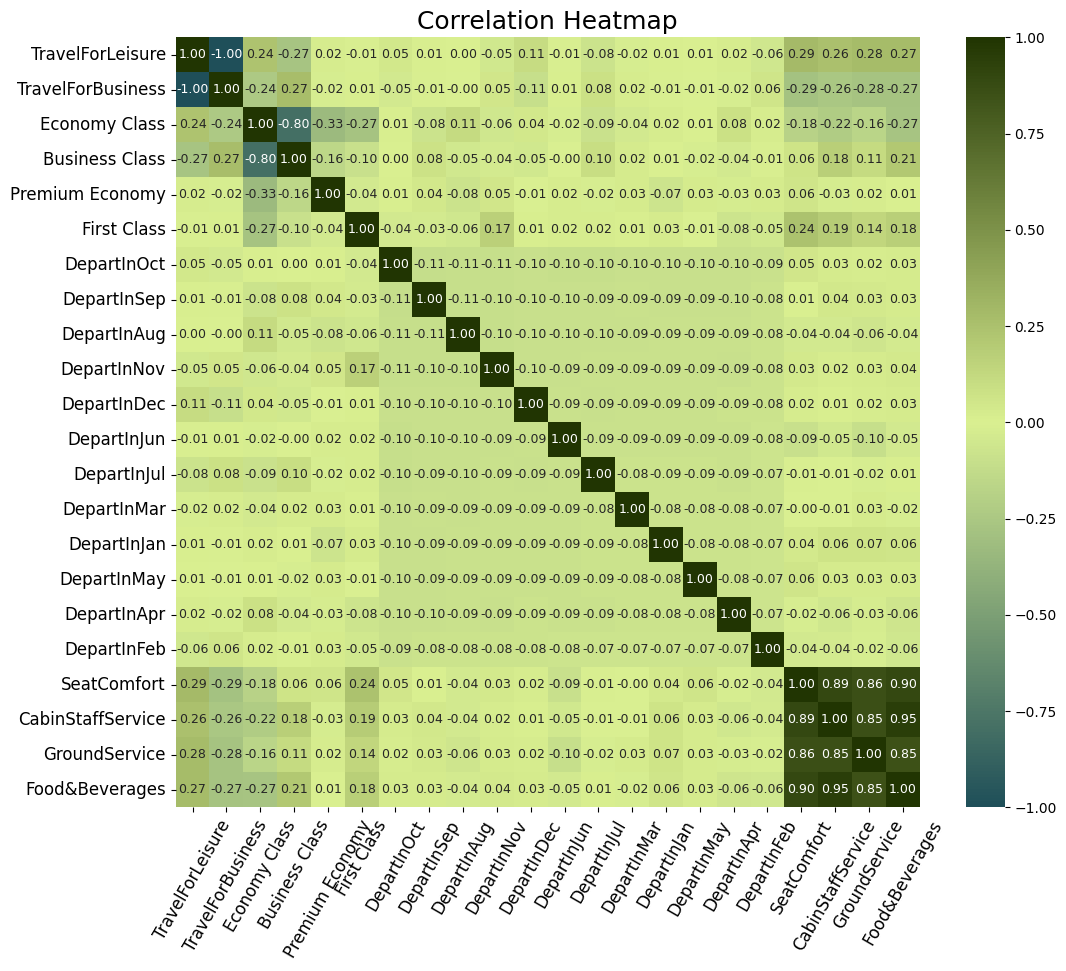

In [19]:
data = pd.read_csv('./data/correlation_analysis.csv')

colors = ['#1F4F59', '#DAF091', '#213502'] 
cmap_name = 'custom_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap=custom_cmap, fmt='.2f', annot_kws={"size": 9})
plt.title('Correlation Heatmap', fontsize=18)
# 设置x轴刻度
plt.xticks(rotation=60, fontsize=12)
# 设置y轴刻度
plt.yticks(fontsize=12)
plt.show()

## 回归评估器的训练可视化

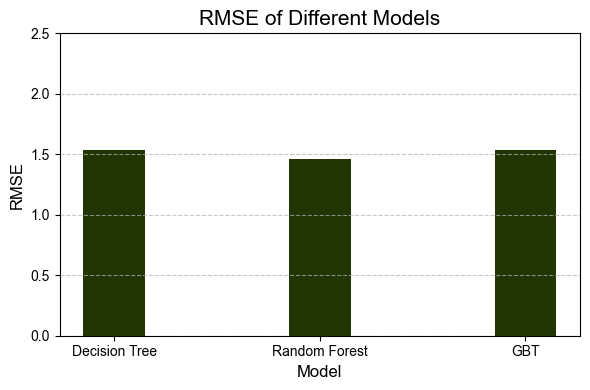

In [19]:
# 读取CSV文件
data = pd.read_csv('./data/rmse_analysis.csv')

# 假设第一列是模型名称，第二列是RMSE
models = data.iloc[:, 0]
rmse_values = data.iloc[:, 1]

# 创建纵向柱状图
plt.figure(figsize=(6, 4))
plt.bar(models, rmse_values, width=0.3, color='#213502')
plt.ylim(0, 2.5)
plt.title('RMSE of Different Models', fontsize=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.grid(False)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 旋转X轴标签以避免重叠
plt.xticks(rotation=0, ha='center')

# 显示图表
plt.tight_layout()
plt.show()


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

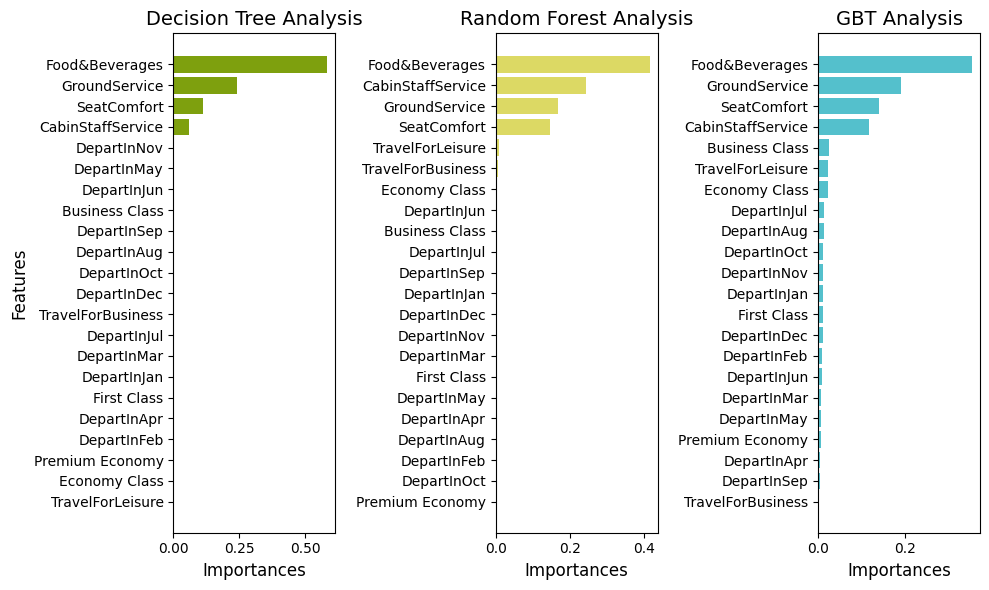

In [20]:
files = [
    ('./data/decision_tree_analysis.csv', 'Decision Tree Analysis'),
    ('./data/random_forest_analysis.csv', 'Random Forest Analysis'),
    ('./data/gbt_analysis.csv', 'GBT Analysis')
]

num_files = len(files)
num_cols = num_files
num_rows = 1
colors = [ '#7EA00E', '#DCD964', '#54C0CC']

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 6))

for i, (file, title) in enumerate(files):
    # 读取CSV文件
    data = pd.read_csv(file)
    data = data.sort_values(by='Importances', ascending=False)
    data.reset_index(drop=True, inplace=True)

    # 假设第一列是类别，第二列是评分
    categories = data.iloc[:, 0]
    categories = categories[::-1]
    values = data.iloc[:, 1]
    values = values[::-1]

    # 绘制横向柱状图
    axes[i].barh(categories, values, color=colors[i])

    axes[i].set_title(title, fontsize=14)
    if i == 0:
        axes[i].set_ylabel('Features', fontsize=12)
    axes[i].set_xlabel('Importances', fontsize=12)
    axes[i].grid(False)


# 调整布局
plt.tight_layout()
plt.show()